dm/dt  =  ṁ_in  −  ṁ_out

In [1]:
# Example 1 from the whiteboard, in Python.
# A tank with one stream in, one stream out. SI units: kg/s.

flow_in = 3.0    # [kg/s]  the tap
flow_out = 2.0   # [kg/s]  the drain

accumulation = flow_in - flow_out   # [kg/s]  THE mass balance

print(f"In:           {flow_in} kg/s")
print(f"Out:          {flow_out} kg/s")
print(f"Accumulation: {accumulation:+} kg/s")

if accumulation > 0:
    print("-> Tank is FILLING")
elif accumulation < 0:
    print("-> Tank is DRAINING")
else:
    print("-> STEADY STATE (in = out)")

# That's the entire equation: dm/dt = m_in - m_out.
# One subtraction. Everything else in this series is bookkeeping around it.

In:           3.0 kg/s
Out:          2.0 kg/s
Accumulation: +1.0 kg/s
-> Tank is FILLING


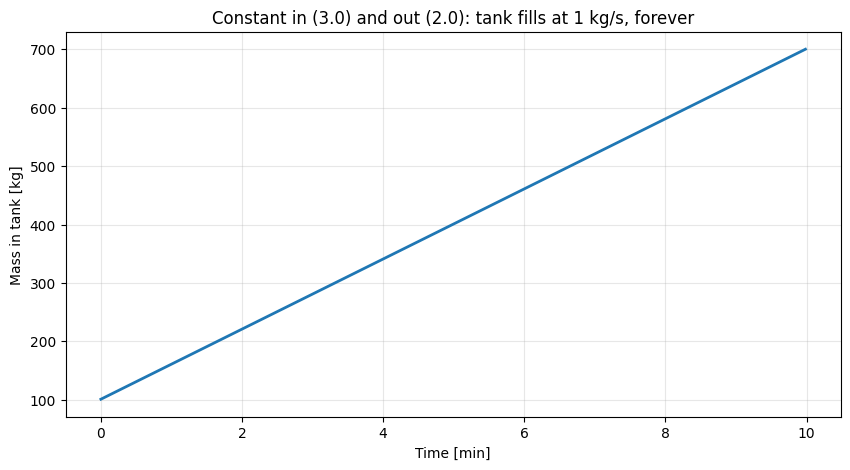

Start mass: 100 kg  ->  End mass: 700 kg
Sanity check: 100 + 1.0 kg/s x 600 s = 700 kg. Does it match?


In [2]:
# Accumulation is a RATE (kg per second). To know the mass in the tank,
# we step through time. Every tick:
#     mass = mass + (in - out) * dt
# This loop is the embryo of the entire physics engine.

import numpy as np
import matplotlib.pyplot as plt

# --- Simulation settings ---
dt = 1.0                  # time step [s] - the "tick" of our clock
t_end = 600.0             # simulate 10 minutes
n_steps = int(t_end / dt)

# --- Tank state ---
mass = 100.0              # what's in the tank at t=0 [kg]

# --- Constant flows for now ---
flow_in = 3.0             # [kg/s]
flow_out = 2.0            # [kg/s]

# --- History (so we can plot afterwards) ---
time_history = []
mass_history = []

for step in range(n_steps):
    t = step * dt

    # THE MASS BALANCE - the only physics in this loop:
    accumulation = flow_in - flow_out          # [kg/s]
    mass = mass + accumulation * dt            # [kg]

    time_history.append(t)
    mass_history.append(mass)

plt.figure(figsize=(10, 5))
plt.plot(np.array(time_history) / 60, mass_history, linewidth=2)
plt.xlabel("Time [min]")
plt.ylabel("Mass in tank [kg]")
plt.title("Constant in (3.0) and out (2.0): tank fills at 1 kg/s, forever")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Start mass: 100 kg  ->  End mass: {mass:.0f} kg")
print(f"Sanity check: 100 + 1.0 kg/s x 600 s = 700 kg. Does it match?")

# A straight line - because nothing pushes back. Real tanks push back:
# the fuller they are, the harder they drain. Next cell.

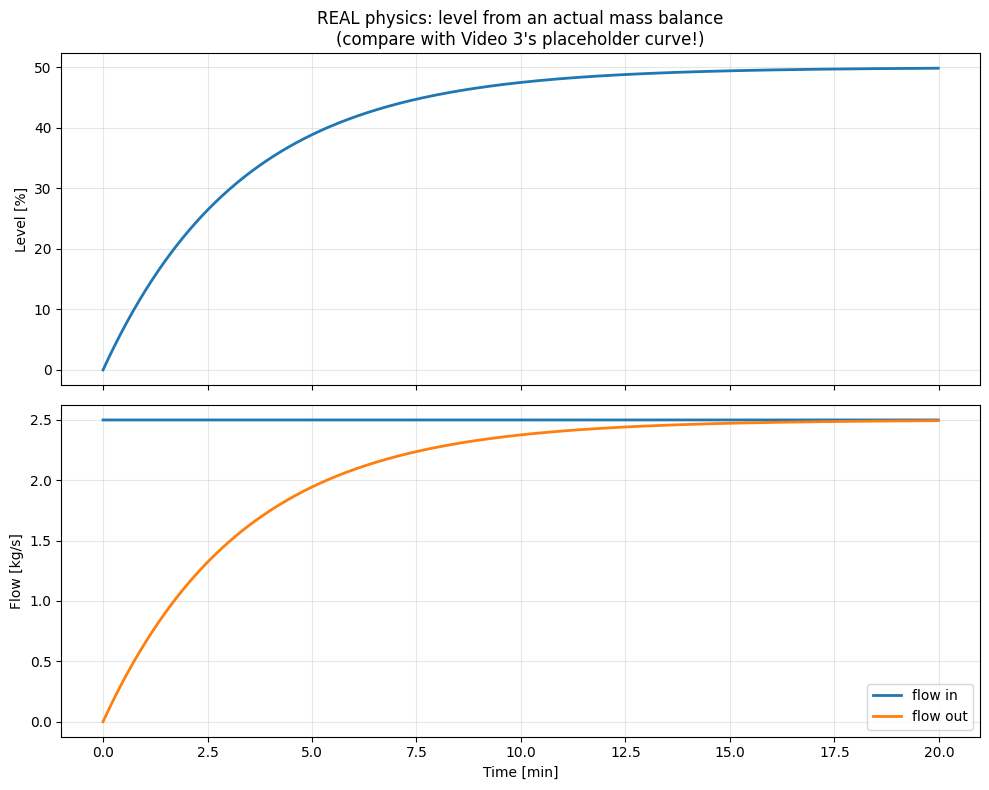

In [3]:
# In a real tank draining by gravity, outflow is NOT constant:
# more liquid above the outlet = more pressure = more outflow.
# Simplest honest version: outflow proportional to level.
#
#     flow_out = k * level
#
# (The proper square-root version of gravity draining comes in Block 2.
#  Proportional keeps today about the BALANCE, not the valve maths.)

# --- Tank geometry ---
area = 0.5                # tank cross-section [m^2]
density = 1000.0          # water [kg/m^3]
tank_height = 2.0         # [m]

# --- Simulation settings ---
dt = 1.0
t_end = 1200.0            # 20 minutes
n_steps = int(t_end / dt)

# --- State ---
mass = 0.0                # start EMPTY

# --- Flows ---
flow_in = 2.5             # constant feed [kg/s]
k_outflow = 2.5           # outflow coefficient [kg/s per metre of level]

time_history, mass_history, level_history = [], [], []
flow_out_history = []

for step in range(n_steps):
    t = step * dt

    # Level follows from mass and geometry:
    level = mass / (density * area)            # [m]

    # Outflow depends on level - the tank "pushes back":
    flow_out = k_outflow * level               # [kg/s]

    # THE MASS BALANCE (same line as always):
    mass = mass + (flow_in - flow_out) * dt

    time_history.append(t)
    mass_history.append(mass)
    level_history.append(level)
    flow_out_history.append(flow_out)

# --- Plot: level over time ---
t_min = np.array(time_history) / 60

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(t_min, np.array(level_history) * 100 / tank_height, linewidth=2)
ax1.set_ylabel("Level [%]")
ax1.set_title("REAL physics: level from an actual mass balance\n"
              "(compare with Video 3's placeholder curve!)")
ax1.grid(True, alpha=0.3)

ax2.plot(t_min, [flow_in] * n_steps, label="flow in", linewidth=2)
ax2.plot(t_min, flow_out_history, label="flow out", linewidth=2)
ax2.set_xlabel("Time [min]")
ax2.set_ylabel("Flow [kg/s]")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Read the plots together:
#  - Early: out << in  ->  big accumulation  ->  level climbs fast.
#  - As level rises, outflow rises, the gap shrinks, the climb slows.
#  - Eventually out ≈ in  ->  accumulation ≈ 0  ->  STEADY STATE.
#
# Nobody drew this curve. It EMERGED from "in minus out, every tick".
# That's the difference between an animation and a simulation.

In [4]:
# Never trust a flat line - check it with numbers.

final_level = level_history[-1]
final_out = flow_out_history[-1]
final_accum = flow_in - final_out

print(f"Flow in (constant):     {flow_in:.4f} kg/s")
print(f"Flow out (final):       {final_out:.4f} kg/s")
print(f"Accumulation (final):   {final_accum:+.4f} kg/s")
print(f"Final level:            {final_level:.3f} m "
      f"({final_level*100/tank_height:.1f}% of tank)")

# Bonus: predict the steady state WITHOUT simulating.
# At steady state: flow_in = k * level  ->  level = flow_in / k
predicted = flow_in / k_outflow
print(f"\nPredicted steady-state level (flow_in / k): {predicted:.3f} m")
print("Simulation and prediction agree -> the balance closes. Physics is honest.")

# Habit for life: after every simulation, ask "does the balance close?"
# In Video 12 we automate this check and make the engine police itself.

Flow in (constant):     2.5000 kg/s
Flow out (final):       2.4939 kg/s
Accumulation (final):   +0.0061 kg/s
Final level:            0.998 m (49.9% of tank)

Predicted steady-state level (flow_in / k): 1.000 m
Simulation and prediction agree -> the balance closes. Physics is honest.


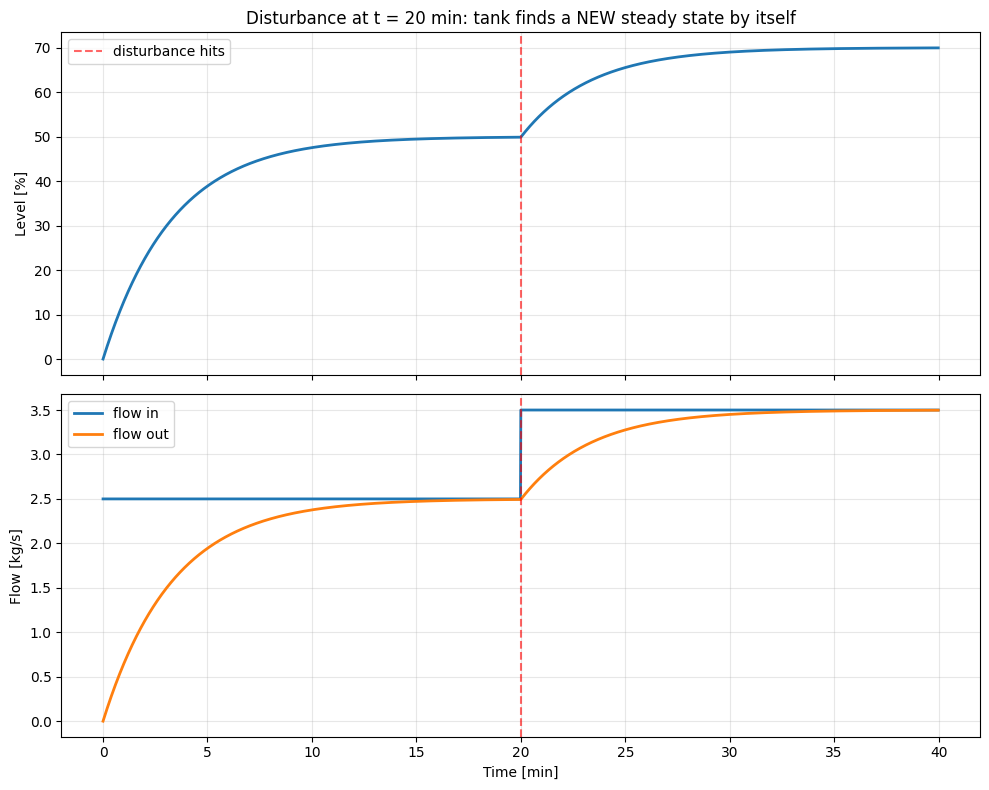

In [5]:
# Halfway through the run, someone upstream starts a second pump:
# inlet flow jumps from 2.5 to 3.5 kg/s. We change NOTHING else.
# No controller exists yet. Watch what the tank does on its own.

dt = 1.0
t_end = 2400.0            # 40 minutes
n_steps = int(t_end / dt)

mass = 0.0
time_history, level_history, flow_in_history, flow_out_history = [], [], [], []

for step in range(n_steps):
    t = step * dt

    # THE DISTURBANCE: at t = 20 min, inlet flow steps up.
    flow_in = 2.5 if t < 1200 else 3.5        # [kg/s]

    level = mass / (density * area)
    flow_out = k_outflow * level
    mass = mass + (flow_in - flow_out) * dt   # same balance, always

    time_history.append(t)
    level_history.append(level)
    flow_in_history.append(flow_in)
    flow_out_history.append(flow_out)

t_min = np.array(time_history) / 60

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(t_min, np.array(level_history) * 100 / tank_height, linewidth=2)
ax1.axvline(20, color="red", linestyle="--", alpha=0.6, label="disturbance hits")
ax1.set_ylabel("Level [%]")
ax1.set_title("Disturbance at t = 20 min: tank finds a NEW steady state by itself")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(t_min, flow_in_history, label="flow in", linewidth=2)
ax2.plot(t_min, flow_out_history, label="flow out", linewidth=2)
ax2.axvline(20, color="red", linestyle="--", alpha=0.6)
ax2.set_xlabel("Time [min]")
ax2.set_ylabel("Flow [kg/s]")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# What happened:
#  1. Old steady state at level = 2.5/2.5 = 1.0 m (50%).
#  2. Disturbance: in > out again -> accumulation returns -> level climbs.
#  3. Rising level pushes outflow up until out = 3.5 -> NEW steady state
#     at level = 3.5/2.5 = 1.4 m (70%).
#
# The tank balanced ITSELF - that's called a self-regulating process.
# But notice the cost: the level moved. If 70% is too high (alarm limit?
# overflow?), self-regulation isn't good enough. That's why controllers
# exist - and that's Block 5.
#
# Also: this cell is the great-grandfather of the fault injection system.
# First time we broke something on purpose. It won't be the last.

## What we built
- The mass balance as code: `mass += (flow_in - flow_out) * dt`
- A time loop — the embryo of the physics engine
- A tank whose level **emerges** from real physics (no faked curves)
- A numerical steady-state check ("does the balance close?")
- Our first disturbance — and a self-regulating process finding a new steady state

## Next video
**Video 4 — Introduction to energy balance.** Same bookkeeping, new currency:
energy in, energy out, energy accumulated. One twist mass never pulls —
energy leaks through walls.
